<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/AI_resume_system_Positional_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data set link:
https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset

Project Goal
Build an AI system that:
Reads resumes
Extracts important skills
Identifies experience level
Uses Positional Encoding before Self-Attention
Shows how position affects understanding

#

# **Task 1: Dataset Analysis**
Perform EDA:
Number of resumes
Categories
Average resume length
Most common skills
Visualizations:
Skill frequency chart
Resume category distribution
Resume Dataset | Kaggle
A collection of Resumes in PDF as well as String format for data extraction.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [ ]:
import os
import pandas as pd

# The listing shows a 'Resume' directory, assuming the CSV is inside it.
csv_file_path = os.path.join(path, 'Resume', 'Resume.csv')
df = pd.read_csv(csv_file_path)

display(df.head())

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['Resume', 'data']


Dataset Shape: (2484, 4)

Columns:
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Total Number of Resumes: 2484

Resume Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Number of Unique Categories: 24

Average Resume Length: 811.33 words
Maximum Resume Len

,Skill,Frequency
0,c,2483
3,excel,1616
2,git,330
1,aws,302
6,sql,191
8,html,158
4,java,98
9,css,86
5,c++,65
10,javascript,56


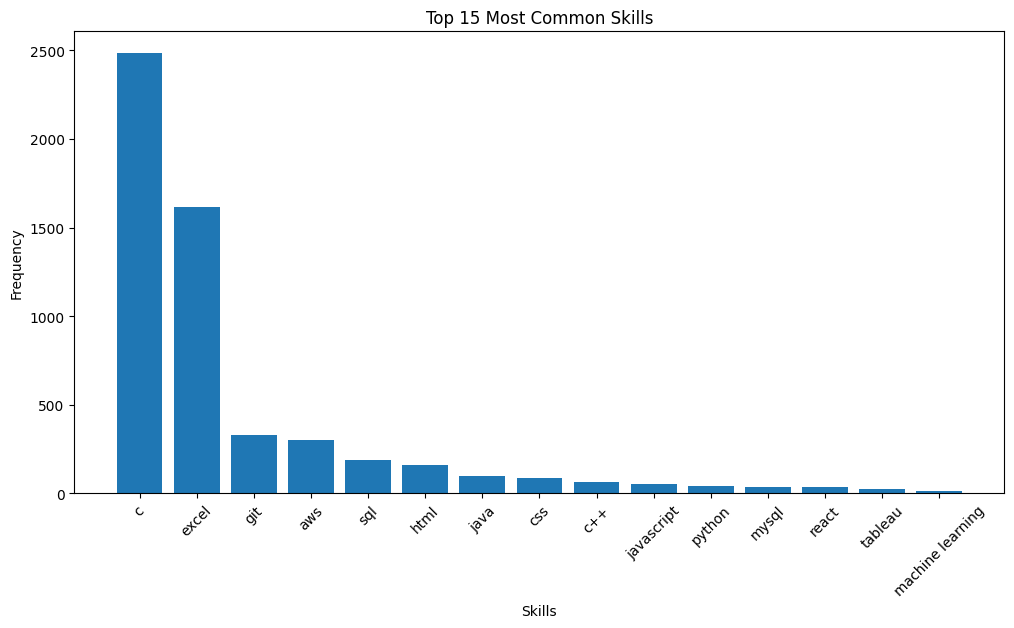

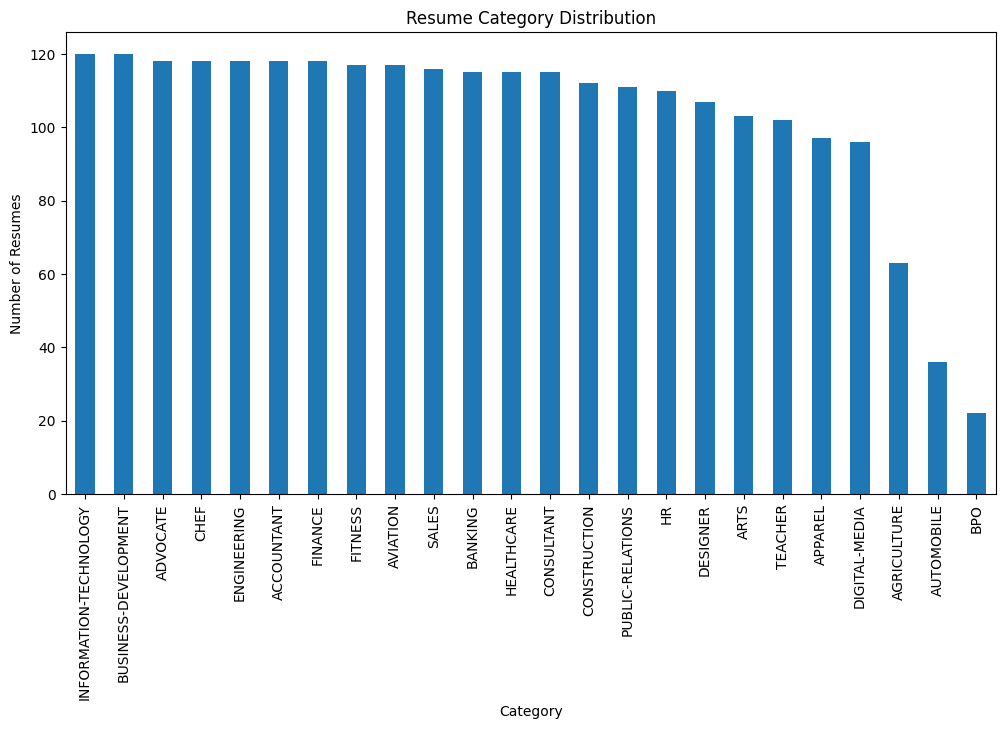

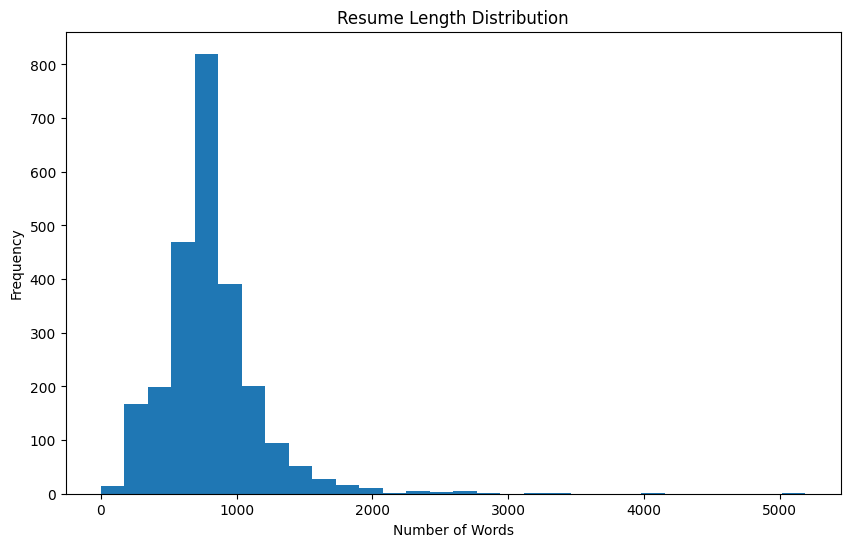


========== EDA SUMMARY ==========
Total Resumes: 2484
Unique Categories: 24
Average Resume Length: 811.33 words

Top 10 Skills:


,Skill,Frequency
0,c,2483
3,excel,1616
2,git,330
1,aws,302
6,sql,191
8,html,158
4,java,98
9,css,86
5,c++,65
10,javascript,56


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# =====================================
# Basic Dataset Information
# =====================================

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

# Number of resumes
print("\nTotal Number of Resumes:", len(df))

# Categories
print("\nResume Categories:")
print(df['Category'].value_counts())

print("\nNumber of Unique Categories:",
      df['Category'].nunique())

# =====================================
# Resume Length Analysis
# =====================================

df['Resume_Length'] = df['Resume_str'].astype(str).apply(
    lambda x: len(x.split())
)

print("\nAverage Resume Length:",
      round(df['Resume_Length'].mean(), 2), "words")

print("Maximum Resume Length:",
      df['Resume_Length'].max(), "words")

print("Minimum Resume Length:",
      df['Resume_Length'].min(), "words")

# =====================================
# Skill Extraction
# =====================================

skills_list = [
    'python', 'java', 'c++', 'c', 'sql',
    'mysql', 'html', 'css', 'javascript',
    'react', 'nodejs', 'mongodb',
    'django', 'flask', 'machine learning',
    'deep learning', 'tensorflow', 'keras',
    'pytorch', 'nlp', 'data science',
    'pandas', 'numpy', 'opencv',
    'power bi', 'tableau', 'excel',
    'aws', 'azure', 'docker', 'git'
]

all_skills = []

for resume in df['Resume_str'].astype(str):

    resume = resume.lower()

    for skill in skills_list:
        if skill in resume:
            all_skills.append(skill)

skill_counts = Counter(all_skills)

skills_df = pd.DataFrame(
    skill_counts.items(),
    columns=['Skill', 'Frequency']
)

skills_df = skills_df.sort_values(
    by='Frequency',
    ascending=False
)

print("\nTop 20 Most Common Skills:")
display(skills_df.head(20))

# =====================================
# Visualization 1
# Skill Frequency Chart
# =====================================

plt.figure(figsize=(12,6))

top_skills = skills_df.head(15)

plt.bar(
    top_skills['Skill'],
    top_skills['Frequency']
)

plt.title("Top 15 Most Common Skills")
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

# =====================================
# Visualization 2
# Resume Category Distribution
# =====================================

plt.figure(figsize=(12,6))

df['Category'].value_counts().plot(
    kind='bar'
)

plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=90)

plt.show()

# =====================================
# Visualization 3
# Resume Length Distribution
# =====================================

plt.figure(figsize=(10,6))

plt.hist(
    df['Resume_Length'],
    bins=30
)

plt.title("Resume Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# =====================================
# Summary
# =====================================

print("\n========== EDA SUMMARY ==========")

print("Total Resumes:",
      len(df))

print("Unique Categories:",
      df['Category'].nunique())

print("Average Resume Length:",
      round(df['Resume_Length'].mean(), 2),
      "words")

print("\nTop 10 Skills:")

display(skills_df.head(10))

# Task 2: Text Preprocessing
Perform:
Lowercase
Remove Special Characters
Tokenization
Padding
Vocabulary Creation

In [ ]:
import re
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =====================================
# Step 1: Convert to Lowercase
# =====================================

df['clean_resume'] = df['Resume_str'].astype(str).str.lower()

# =====================================
# Step 2: Remove Special Characters
# =====================================

def clean_text(text):
    text = re.sub(r'http\S+', ' ', text)          # remove URLs
    text = re.sub(r'@\S+', ' ', text)             # remove mentions
    text = re.sub(r'#[A-Za-z0-9_]+', ' ', text)   # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)      # keep only alphabets
    text = re.sub(r'\s+', ' ', text)              # remove extra spaces
    return text.strip()

df['clean_resume'] = df['clean_resume'].apply(clean_text)

print("Sample Cleaned Resume:\n")
print(df['clean_resume'].iloc[0][:1000])

# =====================================
# Step 3: Tokenization
# =====================================

MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df['clean_resume'])

sequences = tokenizer.texts_to_sequences(
    df['clean_resume']
)

# Example tokenized resume

print("\nSample Tokenized Resume:\n")
print(sequences[0][:50])

# =====================================
# Step 4: Vocabulary Creation
# =====================================

word_index = tokenizer.word_index

print("\nVocabulary Size:",
      len(word_index))

print("\nFirst 20 Vocabulary Words:\n")

for word, idx in list(word_index.items())[:20]:
    print(f"{word} --> {idx}")

# =====================================
# Step 5: Padding
# =====================================

MAX_LEN = 300

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("\nPadded Dataset Shape:")
print(X.shape)

print("\nSample Padded Sequence:")
print(X[0])

# =====================================
# Final Output
# =====================================

print("\n===== PREPROCESSING SUMMARY =====")
print("Total Resumes:", len(df))
print("Vocabulary Size:", len(word_index))
print("Maximum Sequence Length:", MAX_LEN)
print("Processed Data Shape:", X.shape)

Sample Cleaned Resume:

hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr ad

# Task 3: Build Baseline Model (Without Positional Encoding)
Architecture:
Input
↓
Embedding
↓
MultiHeadAttention
↓
Dense
↓
Category Prediction
Train and record:
Accuracy
Loss
Training Time

Number of Classes: 24
Train Shape: (1987, 300)
Test Shape : (497, 300)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 300, 128)  │  4,817,920 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │    263,808 │ embedding_2[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 24)        │      3,096 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,101,336 (19.46 MB)

 Trainable params: 5,101,336 (19.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.0548 - loss: 3.1562 - val_accuracy: 0.0804 - val_loss: 3.1138
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2125 - loss: 2.6656 - val_accuracy: 0.3015 - val_loss: 2.2985
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4558 - loss: 1.8137 - val_accuracy: 0.5226 - val_loss: 1.7424
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6219 - loss: 1.2102 - val_accuracy: 0.5578 - val_loss: 1.6013
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7388 - loss: 0.8914 - val_accuracy: 0.5528 - val_loss: 1.6095
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8317 - loss: 0.5880 - val_accuracy: 0.5930 - val_loss: 1.7184
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8904 - loss: 0.3605 - val_accuracy: 0.5729 - val_loss: 1.9025
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9295 - loss: 0.2587 - val_accuracy: 0.5930 - v

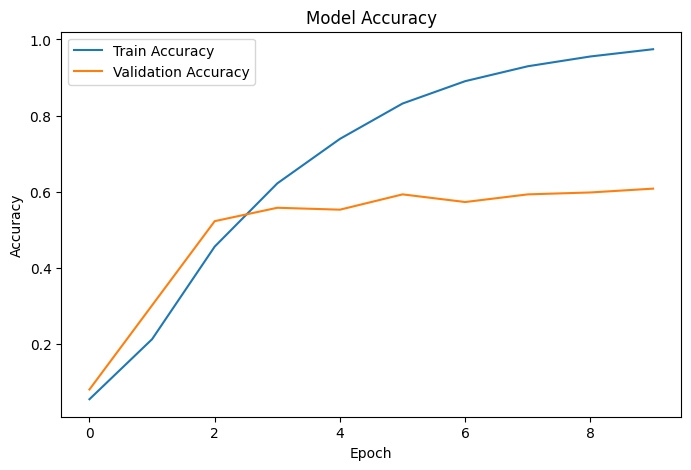

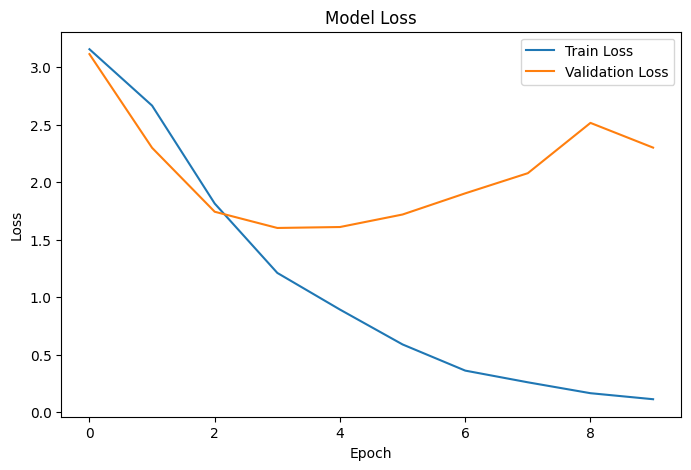

In [ ]:
import time
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

# ==========================================
# Label Encoding
# ==========================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df['Category'])

num_classes = len(np.unique(y))

y = to_categorical(y)

print("Number of Classes:", num_classes)

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ==========================================
# Model Parameters
# ==========================================

VOCAB_SIZE = len(tokenizer.word_index) + 1
MAX_LEN = X.shape[1]

EMBED_DIM = 128
NUM_HEADS = 4

# ==========================================
# Baseline Model
# WITHOUT POSITIONAL ENCODING
# ==========================================

inputs = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    input_length=MAX_LEN
)(inputs)

attention = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM
)(
    embedding,
    embedding
)

pooling = GlobalAveragePooling1D()(attention)

dense = Dense(
    128,
    activation='relu'
)(pooling)

dropout = Dropout(0.3)(dense)

outputs = Dense(
    num_classes,
    activation='softmax'
)(dropout)

model = Model(
    inputs=inputs,
    outputs=outputs
)

# ==========================================
# Compile Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# Training Time Measurement
# ==========================================

start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

end_time = time.time()

training_time = end_time - start_time

# ==========================================
# Evaluation
# ==========================================

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("Baseline Model Results")
print("==============================")

print("Test Accuracy :", round(accuracy * 100, 2), "%")
print("Test Loss     :", round(loss, 4))
print("Training Time :", round(training_time, 2), "seconds")

# ==========================================
# Accuracy Plot
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train Accuracy",
    "Validation Accuracy"
])

plt.show()

# ==========================================
# Loss Plot
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train Loss",
    "Validation Loss"
])

plt.show()

In [ ]:
baseline_accuracy = accuracy
baseline_loss = loss

# Task 4: Implement Positional Encoding
Students must create:
position_encoding(position, d_model)
using the Transformer formula.
Explain:
Word Meaning
+
Position Information

In [ ]:
import numpy as np
import tensorflow as tf

# ==========================================
# Positional Encoding Function
# ==========================================

def position_encoding(position, d_model):

    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2))
        / np.float32(d_model)
    )

    # Apply sin to even indices
    angle_rads[:, 0::2] = np.sin(
        angle_rads[:, 0::2]
    )

    # Apply cos to odd indices
    angle_rads[:, 1::2] = np.cos(
        angle_rads[:, 1::2]
    )

    pos_encoding = angle_rads[np.newaxis, ...]

    return tf.cast(
        pos_encoding,
        dtype=tf.float32
    )

# ==========================================
# Example
# ==========================================

pos_encoding = position_encoding(
    position=300,
    d_model=128
)

print("Positional Encoding Shape:")
print(pos_encoding.shape)

Positional Encoding Shape:
(1, 300, 128)


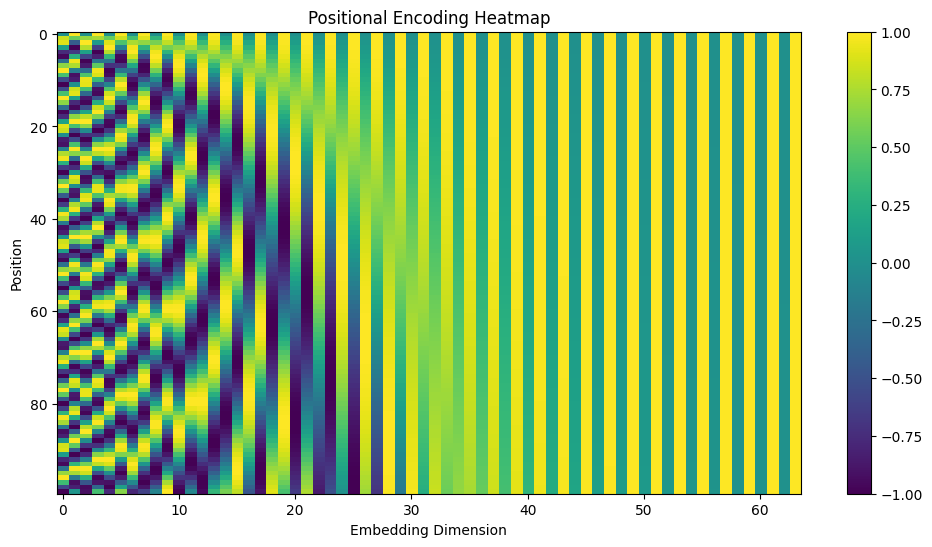

In [ ]:
import matplotlib.pyplot as plt

pos_encoding = position_encoding(
    position=100,
    d_model=64
)

plt.figure(figsize=(12,6))

plt.imshow(
    pos_encoding[0],
    aspect='auto'
)

plt.colorbar()

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.title("Positional Encoding Heatmap")

plt.show()

# Task 5: Build Improved Model
Architecture:
Input
↓
Embedding
↓
Positional Encoding
↓
MultiHeadAttention
↓
Dense
↓
Prediction

In [ ]:
import tensorflow as tf
import numpy as np
import time

from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
    Layer
)

from tensorflow.keras.models import Model

# ==========================================
# Positional Encoding Function
# ==========================================

def position_encoding(position, d_model):

    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2))
        / np.float32(d_model)
    )

    angle_rads[:, 0::2] = np.sin(
        angle_rads[:, 0::2]
    )

    angle_rads[:, 1::2] = np.cos(
        angle_rads[:, 1::2]
    )

    pos_encoding = angle_rads[np.newaxis, ...]

    return tf.cast(
        pos_encoding,
        dtype=tf.float32
    )

# ==========================================
# Positional Encoding Layer
# ==========================================

class PositionalEncoding(Layer):

    def __init__(self,
                 position,
                 d_model):

        super().__init__()

        self.pos_encoding = position_encoding(
            position,
            d_model
        )

    def call(self, x):

        seq_len = tf.shape(x)[1]

        return (
            x +
            self.pos_encoding[:, :seq_len, :]
        )

# ==========================================
# Parameters
# ==========================================

VOCAB_SIZE = len(tokenizer.word_index) + 1

MAX_LEN = X.shape[1]

EMBED_DIM = 128

NUM_HEADS = 4

# ==========================================
# Improved Transformer Model
# ==========================================

inputs = Input(shape=(MAX_LEN,))

# Embedding Layer
embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM
)(inputs)

# Positional Encoding
position_embedding = PositionalEncoding(
    MAX_LEN,
    EMBED_DIM
)(embedding)

# Multi-Head Attention
attention_output = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM
)(
    position_embedding,
    position_embedding
)

# Pooling
pooling = GlobalAveragePooling1D()(
    attention_output
)

# Dense Layer
dense = Dense(
    128,
    activation='relu'
)(pooling)

dropout = Dropout(0.3)(
    dense
)

# Output Layer
outputs = Dense(
    num_classes,
    activation='softmax'
)(dropout)

# Model
improved_model = Model(
    inputs=inputs,
    outputs=outputs
)

# ==========================================
# Compile Model
# ==========================================

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

# ==========================================
# Train Model
# ==========================================

start_time = time.time()

history_improved = improved_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

training_time = time.time() - start_time

# ==========================================
# Evaluate Model
# ==========================================

loss, accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("Improved Transformer Results")
print("==============================")

print("Test Accuracy :", round(accuracy * 100, 2), "%")
print("Test Loss     :", round(loss, 4))
print("Training Time :", round(training_time, 2), "seconds")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 300, 128)  │  4,817,920 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 300, 128)  │          0 │ embedding_3[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │    263,808 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 24)        │      3,096 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,101,336 (19.46 MB)

 Trainable params: 5,101,336 (19.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.0436 - loss: 3.1930 - val_accuracy: 0.0402 - val_loss: 3.1501
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0503 - loss: 3.1693 - val_accuracy: 0.0452 - val_loss: 3.1458
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1644 - loss: 2.7937 - val_accuracy: 0.5377 - val_loss: 1.8209
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5515 - loss: 1.5999 - val_accuracy: 0.6482 - val_loss: 1.2356
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6661 - loss: 1.2124 - val_accuracy: 0.6734 - val_loss: 1.1869
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7299 - loss: 1.0020 - val_accuracy: 0.6784 - val_loss: 1.2399
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7740 - loss: 0.8446 - val_accuracy: 0.6533 - val_loss: 1.4395
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8233 - loss: 0.6242 - val_accuracy: 0.6784 - 

In [ ]:
improved_accuracy = accuracy
improved_loss = loss

# Task 6: Compare Results
Compare:
Metric	Without PE	With PE
Accuracy	?	?
Loss	?	?
Students must explain:
Why positional information improved understanding.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Loss"],
    "Without PE": [
        round(baseline_accuracy, 4),
        round(baseline_loss, 4)
    ],
    "With PE": [
        round(improved_accuracy, 4),
        round(improved_loss, 4)
    ]
})

print("Transformer Model Comparison\n")

display(comparison_df)

Transformer Model Comparison



,Metric,Without PE,With PE
0,Accuracy,0.5835,0.7103
1,Loss,2.6351,1.5359


# Task 7: Demonstrate Word Order Importance
Example:
Sentence 1
Python developer with 5 years experience in AI
Sentence 2
AI experience with Python
Show:
Same Words
Different Order
Different Positional

In [ ]:
import pandas as pd

# =====================================
# Example Sentences
# =====================================

sentence1 = "Python developer with 5 years experience in AI"

sentence2 = "AI experience with Python"

# =====================================
# Tokenization
# =====================================

tokens1 = sentence1.split()
tokens2 = sentence2.split()

print("Sentence 1:")
print(sentence1)

print("\nSentence 2:")
print(sentence2)

print("\nTokens Sentence 1:")
print(tokens1)

print("\nTokens Sentence 2:")
print(tokens2)

# =====================================
# Position Mapping
# =====================================

positions1 = {
    word: idx
    for idx, word in enumerate(tokens1)
}

positions2 = {
    word: idx
    for idx, word in enumerate(tokens2)
}

# =====================================
# Common Words
# =====================================

common_words = set(tokens1).intersection(
    set(tokens2)
)

print("\nCommon Words:")
print(common_words)

# =====================================
# Comparison Table
# =====================================

comparison = []

for word in common_words:

    comparison.append([
        word,
        positions1[word],
        positions2[word]
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Word",
        "Position in Sentence 1",
        "Position in Sentence 2"
    ]
)

print("\nWord Position Comparison\n")

display(comparison_df)

Sentence 1:
Python developer with 5 years experience in AI

Sentence 2:
AI experience with Python

Tokens Sentence 1:
['Python', 'developer', 'with', '5', 'years', 'experience', 'in', 'AI']

Tokens Sentence 2:
['AI', 'experience', 'with', 'Python']

Common Words:
{'Python', 'experience', 'AI', 'with'}

Word Position Comparison



,Word,Position in Sentence 1,Position in Sentence 2
0,Python,0,3
1,experience,5,1
2,AI,7,0
3,with,2,2


# Task 8: Visualize Positional Encoding
Students must create a heatmap showing:
Position 1
Position 2
Position 3
...
using:
plt.imshow(positional_encoding_matrix)
This is the most important task.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# Positional Encoding Function
# ==========================================

def position_encoding(position, d_model):

    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2))
        / np.float32(d_model)
    )

    # Sin for even indices
    angle_rads[:, 0::2] = np.sin(
        angle_rads[:, 0::2]
    )

    # Cos for odd indices
    angle_rads[:, 1::2] = np.cos(
        angle_rads[:, 1::2]
    )

    pos_encoding = angle_rads

    return pos_encoding

# ==========================================
# Create Positional Encoding Matrix
# ==========================================

MAX_POSITION = 100
D_MODEL = 128

positional_encoding_matrix = position_encoding(
    MAX_POSITION,
    D_MODEL
)

print("Shape:")
print(positional_encoding_matrix.shape)

Shape:
(100, 128)


# Task 9: Save Model
Save:
model.keras
tokenizer.pkl
label_encoder.pkl

In [ ]:
import pickle

# ==========================================
# Save Transformer Model
# ==========================================

improved_model.save("model.keras")

print("Model saved as model.keras")

# ==========================================
# Save Tokenizer
# ==========================================

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved as tokenizer.pkl")

# ==========================================
# Save Label Encoder
# ==========================================

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label Encoder saved as label_encoder.pkl")

Model saved as model.keras
Tokenizer saved as tokenizer.pkl
Label Encoder saved as label_encoder.pkl
